# Carl von Ossietzky Universität Oldenburg - Mapping

In [2]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [4]:
client = bigquery.Client(project='subugoe-collaborative')

In [5]:
oal = client.query(f"""
                    SELECT 
                        CASE 
                            WHEN inst_id = 445 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 6612 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 316 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 315 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 690 THEN 'Oldenburger Institut für Informatik'
                            WHEN inst_id = 5488 THEN 'Helmholtz-Institut für Funktionelle Marine Biodiversität'
                            WHEN inst_id = 4564 THEN 'Institute for Science Networking Oldenburg GmbH'
                            ELSE 'not assigned'
                        END AS fak_name,
                        'Carl von Ossietzky Universität Oldenburg' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, kb_inst.inst_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.inst_id IN (
                              99, -- 'Carl von Ossietzky Universität Oldenburg'
                              445, -- 'Evangelisches Krankenhaus Oldenburg'
                              6612, -- 'UMO - Universitätsmedizin Oldenburg'
                              316, -- 'Klinikum Oldenburg gGmbH'
                              315, -- 'Pius-Hospital Oldenburg'
                              5488, -- 'Helmholtz-Institut für Funktionelle Marine Biodiversität an der Universität Oldenburg (HIFMB)'
                              4564, -- Institute for Science Networking Oldenburg GmbH
                              690 -- Oldenburger Institut für Informatik
                          )
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [6]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Carl von Ossietzky Universität Oldenburg,"Carl von Ossietzky Universit&#x00E4;t,Departme...",https://openalex.org/W4312296617
1,Oldenburger Institut für Informatik,Carl von Ossietzky Universität Oldenburg,"Bauhaus-Universität Weimar, Germany and OFFIS ...",https://openalex.org/W4224992634
2,not assigned,Carl von Ossietzky Universität Oldenburg,"Pharmacology and Toxicology, Department of Hum...",https://openalex.org/W4309721564
3,not assigned,Carl von Ossietzky Universität Oldenburg,"Department of Psychiatry, School of Medicine &...",https://openalex.org/W4283158321
4,not assigned,Carl von Ossietzky Universität Oldenburg,"University of Oldenburg, School of Cultural St...",https://openalex.org/W4306385597


In [7]:
#oal.replace({'Universitätsmedizin Oldenburg': 'Fakultät VI - Medizin und Gesundheitswissenschaften'}, inplace=True)

In [9]:
MAPPING_DICT = {
    'Bibliotheks- und Informationssystem (BIS)': ['informationssystem'],
    'Center für lebenslanges Lernen (C3L)': ['lifelong learning', 'center für lebenslanges lernen'],
    #'CMC - Center for Migration, Education and Cultural Studies': [],
    'COAST - Zentrum für Umwelt- und Nachhaltigkeitsforschung': ['sustainability research', 'coast-zentrum'],
    #'ecco-ecology + communication Unternehmensberatung GmbH': [],
    'Helmholtz-Institut für Funktionelle Marine Biodiversität': ['(hifmb)', 'helm(h)?oltz(-|‐|\s)?institute'], # selbst ergänzt
    'ForWind - Zentrum für Windenergieforschung': ['wind energy', 'forwind'],
    'Forschungszentrum Neurosensorik': ['cent(re|er)( for| of)? neurosensory', 'forschungszentrum( für)? neurosensorik', 'ag ("|‘)(neuro)?sens'],
    'Fakultät I - Bildungs- und Sozialwissenschaften': ['(department|institute) (for|of) social science', '(school|institute|faculty|department) of education(al)?', 
                                                        'educational science', 'special (education|needs)', 'lernforschung', 'education and rehabilitation',
                                                        'rehabilitationspädagogi(sch|k)', 'research on learning', 'pedagogy', 'schooling',
                                                        '(open|political|continuing) (education|theory)', 'department i educational',
                                                        'sozialwissenschaft(liche|en)', '(?<!religions)(?<!wirtschafts)päd(a)?gogik', 'social sciences institute'
                                                       ],
    'Fakultät II - Informatik, Wirtschafts- und Rechtswissenschaften': ['(business|energy) (informati(on|cs)|application|administration)', 
                                                                        'applied artific(i)?al intelligence', 'information technology',
                                                                        'digitalized', '(department|fachbereich|media)( of| für)? (economics|informati(k|cs)|business)', 
                                                                        'comput(er|ing) science', 'offis', 'sustainable information', 'economic(s and)? law', 
                                                                        'resilience learning', 'vwl', 'marketing', 'safety-security', 'economic education',
                                                                        'interconnected systems', '(public|ecological) economics', 'wirtschaftspädagogik', 'micro(-)?robotics',
                                                                        'rechtswissenschaften', 'finance and banking', 'medieninformatik', 
                                                                        'software engineering', 'accounting', 'innovation', 'formale sprachen', 
                                                                        'informatics (department|education)', 'embedded hardware', 'computational intelligence', 
                                                                        'safety and explainability', 'betriebswirtschaft', 'chair of management',
                                                                        'information law'
                                                                       ],
    'Fakultät III - Sprach- und Kulturwissenschaften': ['(institut(e)?|department) (of|für) musi(k|c)', 'kulturwissenschaften',
                                                        'department of (german|dutch)', 'visuelle kultur', '(german|american|slavic|dutch) studies',
                                                        'musicology', 'linguistics', '(niederland|sla(w|v)|german)istik', 'slavic department', 
                                                        'speech and music lab'
                                                       ],
    'Fakultät IV - Human- und Gesellschaftswissenschaften': ['philosoph(ie|y)', 'department of history', 'religionspädagogik', 'institut für geschichte',
                                                             'so(z|c)iolog(ie|y)', 'historisches institut', 'school iv', 'institute of history',
                                                             'theolog(ie|y)', 'sportwissenschaft', 'fak. iv', 'sport(s)? science', '(early modern|european) history'
                                                            ],
    'Fakultät V - Mathematik und Naturwissenschaften': ['(icbm)', 'chemi(e|stry) (und|and) biolog(ie|y)', 'industrial chemistry',
                                                        '(ins(t)?(i)?tut(e)?|department|school) (of|f(ü|u|ue)?r|at|for) (ch(e)?mi(e|stry)|physi(k|cs)|biolog(ie|y))', 
                                                        'animal navigation', 'biologie und umweltwissenschaften',
                                                        '(environmental|natural) science', 'nanoscale', 'mathemati(k|cs|sches)', 
                                                        'dida(k|c)ti(k|cs) (der|of) (chemi(e|stry)|physi(k|cs))', 'geodiversity',
                                                        '(physics|chemistry) department', 'sustainable energy', '(landscape|aquatic) ecology', 'geology', 
                                                        '(angewandte|technische|applied|physical|theoretical|organische|marine) chemi(e|stry)', 
                                                        'chemical engineering', 'ecology of plants', 'theoretical physic', 'gewässerökologie',
                                                        'evolutionsbiologie', 'marine sensor(ik|s)', 'genomics', 'evolutionary biology', '(plant|functional) ecology',
                                                        '(chemistry|physics) education', 'soil sci.', 'marine biodiversit', 'plant biodiversity',
                                                        'chemical technology'
                                                       ],
    'Fakultät VI - Medizin und Gesundheitswissenschaften': ['neuro(science|surgery|log(ie|y)|imaging|wissenschaften)', 'anatom(ie|y)', 'health(\s)?(service|science|care)', 
                                                            'department of psychology', 'microbiology', 'laboratory medicine',
                                                            'geriatric', 'dermatology', 'allergologie', 'human medicine', 'gyn(a)?ecology', 'ophthalmology',
                                                            'acoust(.|ics)', 'surgery', 'fa(c|k)ult(ät|y) (6|vi)', 'pulmonology',  
                                                            'psychiatr(ie|y)', 'machine learning division', 'urology',
                                                            'hearing', 'versorgungsforschung', 'gesundheit', 'h(ä|e)matolog(ie|y)', 'oncology',
                                                            'psycholog(ie|y)', 'geneti(k|cs)', 'biometr(ie|y)', 'medizinische (physik|informatik)', 
                                                            'toxicology', 'clinical diagnostics', 'public health', 'medizintechnik',
                                                            'ernährung und funktionalität', 'medical device', 'big data in medicine',
                                                            'intensivmedizin', 'psychosomatik', 'pediatrics', 'klinische chemie',
                                                            'ohrenheilkunde', 'psychological methods', 'signal processing', 'space environment',
                                                            'immunol(.|ogy)', 'ethics in medicine', 'internal medicine',
                                                            'medical (phys(.|ics)|informatics|technolog|radiation)', 
                                                            'ethik in der medizin', 'anesthesiology', 'pädiatrie', 'psychosomatic', 'allgemeinmedizin',
                                                            'otorhinolaryngology', 'emergency', 'ambulante', 'pathologie',
                                                            'ai4health', 'rehabilitation research'
                                                          ],
    'Hochschulsport': ['sport(s)? cent(re|er)'],
    'Institute for Science Networking Oldenburg GmbH': ['science networking oldenburg'],
    #'Oldenburger Fortbildungszentrum (OFZ)': [],
    #'Zentrum für interdisziplinäre Frauen- und Geschlechterforschung (ZFG)': [],
    #'Zentrum für Lehrkräftebildung - Didaktisches Zentrum (DIZ)': [],
    'Universitätsmedizin Oldenburg': ['universitätsmedizin', 'klinik', 'hospital', 'krankenhaus', 'gastroenterolog(ie|y)', 'oldenburg clinic',
                                      'universit(y|äts)(\s)?(klinik|medi(c|z)in(e)?)', 'pius', 'klinikum oldenburg', 'department of cardiology',
                                      'cardiology research group',
                                      'radiolog(ie|y)', '(medical|medizinischer) (k|c)ampus', 'university medicine', 'general practice', ] # selbst ergänzt
}

In [10]:
with open('./mapping_tables_fak/oldenburg.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [11]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [12]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [13]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,"Fakultät II - Informatik, Wirtschafts- und Rec...",Carl von Ossietzky Universität Oldenburg,"Carl von Ossietzky Universit&#x00E4;t,Departme...",https://openalex.org/W4312296617
1,Oldenburger Institut für Informatik,Carl von Ossietzky Universität Oldenburg,"Bauhaus-Universität Weimar, Germany and OFFIS ...",https://openalex.org/W4224992634
2,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Pharmacology and Toxicology, Department of Hum...",https://openalex.org/W4309721564
3,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Department of Psychiatry, School of Medicine &...",https://openalex.org/W4283158321
4,Fakultät III - Sprach- und Kulturwissenschaften,Carl von Ossietzky Universität Oldenburg,"University of Oldenburg, School of Cultural St...",https://openalex.org/W4306385597
...,...,...,...,...
14586,Fakultät V - Mathematik und Naturwissenschaften,Carl von Ossietzky Universität Oldenburg,Department of Chemistry University of Oldenbur...,https://openalex.org/W4250449602
14587,Fakultät V - Mathematik und Naturwissenschaften,Carl von Ossietzky Universität Oldenburg,"Department of Chemistry, University of Oldenbu...",https://openalex.org/W4250449602
14588,Fakultät V - Mathematik und Naturwissenschaften,Carl von Ossietzky Universität Oldenburg,"Institute of Physics, Carl von Ossietzky Unive...",https://openalex.org/W3011064920
14589,Fakultät V - Mathematik und Naturwissenschaften,Carl von Ossietzky Universität Oldenburg,Institute of Physics Carl von Ossietzky Univer...,https://openalex.org/W3011064920


In [14]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()

array(['University of Oldenburg (Carl von Ossietzky Universität Oldenburg, Ammerländer Heerstr. 114, D- 26129 Oldenburg - Germany)',
       'Carl von Ossietzky Universität Oldenburg, Oldenburg, Germany',
       'University of Oldenburg',
       'Carl von Ossietzky Universität Oldenburg, Germany',
       'Carl von Ossietzky University, Oldenburg, Germany',
       'Carl-von-Ossietzky UniversityOldenburg, Germany',
       'Carl von Ossietzky University of Oldenburg,German Aerospace Center (DLR),Sankt Augustin and Ulm,Germany',
       'Carl von Ossietzky University of Oldenburg,ITK Engineering GmbH,Braunschweig,Germany',
       'ITK Engineering GmbH, Carl von Ossietzky University of Oldenburg, Braunschweig, Germany',
       'German Aerospace Center (DLR), Carl von Ossietzky University of Oldenburg, Sankt Augustin and Ulm, Germany',
       'Marco Grawunder (University of Oldenburg, Germany);',
       'University of Oldenburg , Oldenburg , Germany',
       'University of Oldenburg , , Carl-v

In [15]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Bibliotheks- und Informationssystem (BIS),6
1,COAST - Zentrum für Umwelt- und Nachhaltigkeit...,13
2,Center für lebenslanges Lernen (C3L),4
3,Fakultät I - Bildungs- und Sozialwissenschaften,344
4,"Fakultät II - Informatik, Wirtschafts- und Rec...",651
5,Fakultät III - Sprach- und Kulturwissenschaften,129
6,Fakultät IV - Human- und Gesellschaftswissensc...,191
7,Fakultät V - Mathematik und Naturwissenschaften,3546
8,Fakultät VI - Medizin und Gesundheitswissensch...,3753
9,ForWind - Zentrum für Windenergieforschung,186


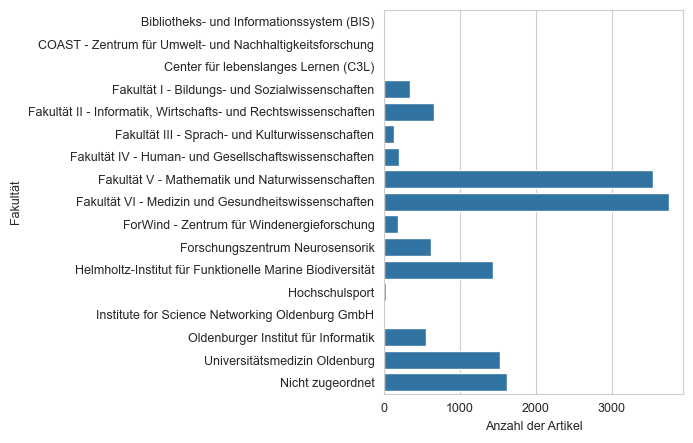

In [16]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [17]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.8890411897745185

In [18]:
MAPPING_DICT_DEPT = {
    'Fakultät I - Bildungs- und Sozialwissenschaften': {
        'Institut für Pädagogik': ['institut für päd(a)?gogik', '(department|institute) (of|for) (pedagogy|educational science)', 'educational psychology',
                                   'empirical research on learning', 'center for open education', 'lehr-lernforschung', 'institute of education'
                                  ],
        'Institut für Sonder- und Rehabilitatiospädagogik': ['special (educational )?(needs|education)', 'rehabilitation'],
        'Institut für Sozialwissenschaften': ['(institute|department) (for|of) social science', 'institut (für|fÃ¼r) sozialwissenschaften', 
                                              'political (theory|education)', 'social sciences institute', 'sozialwissenschaftliche theorie'
                                             ],
    },
    'Fakultät II - Informatik, Wirtschafts- und Rechtswissenschaften': {
        'Department für Informatik': ['informatics education', 'institute (for|of) information technology', '(media|business|energy) informatics', 
                                      'dep(t.|ar(t)?(e)?ment) (of( of)?|for|für) (comput(er|ing) science|informati(k|cs))', 'digitalized energy', 
                                      'medieninformatik', 'sustainable information',
                                      'distributed control', '(artific(i)?al|computational) intelligence', 'fachbereich informatik', 'formale sprachen',
                                      'offis', 'explainability', 'comput(er|ing) science department', 'business application', 'micro(-)?roboti(k|cs)',
                                      'resilience learning', 'software engineering', 'embedded'
                                     ],
        'Department für Wirtschafts- und Rechtswissenschaften': ['institute of economics', 'department of (business administration|economics)', 
                                                                 '(economic|environmental) law', 'wirtschaftspädagogik', 'rechtswissenschaften',
                                                                 'innovation', 'ecological economic', 'vwl', 'finance and banking', 'accounting',
                                                                 'marketing', 'betriebswirtschaft'
                                                                ],
    },
    'Fakultät III - Sprach- und Kulturwissenschaften': {
        'Institut für Anglistik und Amerikanistik': ['amerikanistik', 'anglistik', 'american studies'],
        'Institut für Germanistik': ['germanistik', 'german (studies|language)', 'department of german'],
        'Institut für Kunst und visuelle Kultur': ['visuelle kultur'],
        'Institut für Materielle Kultur': ['materielle kultur'],
        'Institut für Musik': ['musi(k|c)'],
        'Institut für Niederlandistik': ['niederlandistik', 'dutch studies', 'department of dutch'],
        'Institut für Slavistik': ['sla(w|v)istik', 'slavic (studies|department)'],
    },
    'Fakultät IV - Human- und Gesellschaftswissenschaften': {
        'Institut für Evangelische Theologie und Religionspädagogik': ['theolog(ie|y)'],
        'Institut für Geschichte': ['geschichte', 'history'],
        'Institut für Philosophie': ['philosoph(ie|y)'],
        'Institut für Sportwissenschaft': ['sport(s)? science', 'sportwissenschaft', 'so(z|c)iolog(ie|y)'],
    },
    'Fakultät V - Mathematik und Naturwissenschaften': {
        'Institut für Biologie und Umweltwissenschaften (IBU)': ['environmental (science|planning)', 'umweltwissenschaften', 'hydrolog(ie|y)', 'soil sci',
                                                                 '(landscape|plant|functional|aquatic) ecology', 'biodiversity', 
                                                                 'institut(e)? (für|for) biolog(ie|y)', 'neurosensor(ik|y)',
                                                                 'ecological genomics', 'evolutionsbiologie', 'gewässerökologie'
                                                                ],
        'Institut für Chemie (IfC)': ['(department|institut(e)?) (of|for|für) chemi(e|stry)(?!\sand)(?!\sund)', 'chemistry education', 
                                      '(organische|technische|angewandte) chemie',
                                      'didaktik der chemie', '(industrial|applied|physical|theoretical) chemistry', 'chemistry department',
                                      'chemical engineering'
                                     ],
        'Institut für Chemie und Biologie des Meeres (ICBM)': ['marine', 'meeres', 'icbm', 'institut(e)? (for|für) chemi(e|stry)'],
        'Institut für Mathematik (IFM)': ['(department|institut(e)?|school|inst.) (of|for|für|fÃ¼r|f(u)?r) mathemati(k|c)', 'mathematisches institut'],
        'Institut für Physik (IFP)': ['physi(k|cs)', 'nanoscale'],
    },
    'Fakultät VI - Medizin und Gesundheitswissenschaften': {
        'Department für Humanmedizin': ['human(\s)?medi(z|c)in', 'toxi(k|c)olog(ie|y)', 'mi(k|c)robiolog(ie|y)', 'neurosurgery', 'immunol(.|og(ie|y))',
                                        'ophthalmology', 'klinische chemie', 'dermatolog(ie|y)', 'pediatric', 'anatom(ie|y)', 'human genetics',
                                        'clinical chemistry', 'perinatal neurobiology', 'oncology', 'otorhinolaryngology', 'ohrenheilkunde',
                                        'intensivmedizin', 'urolog(ie|y)', 'gyn(a)?ecology', 'emergency', 'otolaryngology', 'genetics of childhood',
                                        '(cardiac|visceral|orthopaedic) surgery', 'anesthesiology', 'haematology', 'inflammation', 'internal medicine', 
                                        'humangenetik', 'medical education', 'psychiatry', 'psychotherap(ie|y)'
                                       ],
        'Department für Neurowissenschaften': ['neurolog(ie|y)', 'neuroscience', 'neurogenetics', 'neurosensory'],
        'Department für Psychologie': ['psycholog(ie|y)', 'psychological'],
        'Department für Versorgungsforschung': ['versorgungsforschung', 'health services research', 'ethi(k|cs)', 'epidemiolog(ie|y)',
                                                'assistance systems', 'assistenzsysteme', 'geriatri(e|c)', 'informatics', 'device technology',
                                                'allgemeinmedizin', 'ai4health', 'big data', 'assistive', 'medizinische informatik',
                                                'ernährung und funktionalität'
                                               ],
        'Department Medizinische Physik und Akustik': ['a(k|c)(o)?usti(k|c)', 'medizinische physik', 'hearing', 'radiation', 'signal processing',
                                                       'acoust.', 'machine learning', 'medical phys.'
                                                      ],
        'European Medical School Oldenburg-Groningen': ['european medical'],
        'Universitätsinstitut für Medizinische Genetik': ['medizinische genetik', 'medical genetics'],
        'Neuroimaging Unit': ['neuroimaging unit'] # selbst ergänzt
    }
}

In [19]:
with open('./mapping_tables_dept/oldenburg.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [20]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [21]:
current_faculty = 'Fakultät VI - Medizin und Gesundheitswissenschaften'

In [22]:
df_with_inst.loc[df_with_inst['fak_name'] == current_faculty, 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == current_faculty]['raw_affiliation_string'].apply(map_dept, 
                                                                                                  faculty=current_faculty)

In [23]:
df_with_inst[(df_with_inst['fak_name'] == current_faculty) & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[:20]

array(['School of Medicine and Health Sciences, University of Oldenburg , , Heiligengeisthöfe 4, 26121 Oldenburg, Germany',
       'School of Medicine and Health Sciences, University of Oldenburg , , Ammerländer Heerstraβe 114–118, 26129 Oldenburg, Germany',
       'School of Medicine and Health Services, Oldenburg University, Oldenburg, Germany',
       'School of Medicine and Health Sciences, Carl von Ossietzky University of Oldenburg, Oldenburg, Germany',
       'School of Medicine and Health Sciences, University of Oldenburg, Oldenburg, Germany',
       'School of Medicine and Health Sciences, University of Oldenburg',
       'Carl von Ossietzky Universität Oldenburg, Fakultät VI – Medizin und Gesundheitswissenschaften, Oldenburg, Deutschland',
       'Faculty of Medicine and Health Sciences, Carl von Ossietzky University, Oldenburg, Germany',
       'University Hospital Bonn, School of Medicine and Health Sciences, University of Oldenburg',
       'Department of Health Care Resear

In [24]:
df_with_inst[df_with_inst['fak_name'] == current_faculty].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,Department Medizinische Physik und Akustik,817
1,Department für Humanmedizin,1266
2,Department für Neurowissenschaften,159
3,Department für Psychologie,455
4,Department für Versorgungsforschung,773
5,European Medical School Oldenburg-Groningen,22
6,Neuroimaging Unit,6
7,Universitätsinstitut für Medizinische Genetik,25
8,NaN,230


In [25]:
df_with_inst[df_with_inst['fak_name'] == current_faculty]

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
2,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Pharmacology and Toxicology, Department of Hum...",https://openalex.org/W4309721564,Department für Humanmedizin
3,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Department of Psychiatry, School of Medicine &...",https://openalex.org/W4283158321,Department für Humanmedizin
6,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Division of Biochemistry, Department of Neuros...",https://openalex.org/W4313503282,Department für Neurowissenschaften
7,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Division of Anatomy, Department of Human Medic...",https://openalex.org/W4313503282,Department für Humanmedizin
17,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,Division for Organizational Health Services Re...,https://openalex.org/W4295366595,Department für Versorgungsforschung
...,...,...,...,...,...
14550,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,Department of Medical Physics and Acoustics an...,https://openalex.org/W3113233942,Department Medizinische Physik und Akustik
14551,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Prof. Dr., DGNR, Klinikum Bremen-Ost, ...",https://openalex.org/W3081594783,Department für Humanmedizin
14569,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Assistive Systems&Medical Technologies, Carl v...",https://openalex.org/W3121846731,Department für Versorgungsforschung
14579,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Carl von Ossietzky University Oldenburg, Dep. ...",https://openalex.org/W3036960818,Department für Versorgungsforschung


In [26]:
MAPPING_DICT_INST = {
    'Institut für Pädagogik': {
        'Arbeitsbereich Bildungsmanagement': ['management'],
        'Arbeitsbereich Didaktik des Sachunterrichts': ['sachunterricht', 'teaching'],
        'Arbeitsbereich Pädagogik und Didaktik der Elementar- und Primarbildung': ['primar'],
        #'Arbeitsgruppe Pädagogik': [],
    },
    'Institut für Sonder- und Rehabilitatiospädagogik': {
        #'Fachgruppe Heterogenität und Diversität unter besonderer Berücksichtigung inklusiver Bildungsprozesse': [],
        #'Fachgruppe Pädagogik bei Verhaltensstörungen - emotionale und soziale Entwicklung': [],
        'Fachgruppe Pädagogik und Didaktik bei Beeinträchtigungen der körperlichen und motorischen Entwicklung sowie chronischen und progredienten Erkrankungen': [
            'progredienten', 'progressive'
        ],
        #'Fachgruppe Pädagogik und Didaktik bei Beeinträchtigungen des Lernens': [],
        #'Fachgruppe Sonder- und Rehabilitationspädagogische Psychologie': [],
        #'Fachgruppe Sprache und Kommunikation und ihre sonderpädagogische Förderung unter besonderer Berücksichtigung inklusiver Bildungsprozesse': [],
    },
    'Institut für Sozialwissenschaften': {
        'Abteilung für politische Bildung und Politikdidaktik': ['politi(k|cs)'],
    },
    'Department für Informatik': {
        'Abteilung Business Engineering': ['business informatics'],
        'Abteilung Digitalisierte Energiesysteme': ['digitalized energy'],
        'Abteilung Eingebettete Hardware-/Software-Systeme': ['embedded hardware'],
        'Abteilung Energieinformatik': ['energy informatics'],
        #'Abteilung Entwicklung korrekter Systeme': [],
        'Abteilung Formale Sprachen': ['formale sprache'],
        #'Abteilung für Safety-Security-Interaction': [],
        #'Abteilung Informationssysteme': [],
        'Abteilung Mikrorobotik und Regelungstechnik': ['mi(k|c)ro(-)?roboti(k|c)'],
        'Abteilung Parallele Systeme': ['parallel systems'],
        #'Abteilung Rechnernetze und Telekommunikation': [],
        #'Abteilung Sicherheitskritische eingebettete Systeme': [],
        'Abteilung Systemsoftware und verteilte Systeme': ['distributed'],
        'Abteilung Umweltinformatik': ['umweltinformatik'],
        'Abteilung Wirtschaftsinformatik - Umwelt und Nachhaltigkeit': ['sustainable information'],
        'Abteilung Wirtschaftsinformatik I / VLBA': ['large business', 'vlba'],
        #'Arbeitsgruppe Data Science': [],
        #'Hardware-Labor': [],
        #'Software-Labor': [],
    },
    'Department für Wirtschafts- und Rechtswissenschaften': {
        'Institut für Betriebswirtschaftslehre und Wirtschaftspädagogik': ['pädagogik', 'ecological economics', 'banking'],
        'Institut für Rechtswissenschaften': ['economic law'],
        'Institut für Volkswirtschaftslehre': ['volkswirtschaftslehre', 'institute of economics'],
        'Institut für Ökonomische Bildung': ['ökonomische bildung', 'education'],
    },
    'Institut für Biologie und Umweltwissenschaften (IBU)': {
        'Arbeitsgruppe Biodiversität und Evolution der Pflanzen': ['plant(s)? biodiversity'],
        'Arbeitsgruppe Biodiversität und Evolution der Tiere': ['evolution der tiere', 'animal biodiversity'],
        #'Arbeitsgruppe Bodenkunde': [],
        #'Arbeitsgruppe Evolutionäre Genetik der Pflanzen': [],
        'Arbeitsgruppe Funktionelle Ökologie der Pflanzen': ['functional ecology', 'plant ecology'],
        'Arbeitsgruppe Hydrogeologie und Landschaftwasserhaushalt': ['hydrogeolog(ie|y)'],
        'Arbeitsgruppe Landschaftsökologie': ['landscape ecology'],
        'Arbeitsgruppe Navigationsbiologie': ['animal navigation'],
        'Arbeitsgruppe Neurosensorik': ['sensor(ik|y)'],
        'Arbeitsgruppe Systematik und Evolutionsbiologie': ['systemati(k|cs)'],
        'Arbeitsgruppe Ökologische Genomik': ['genomics'],
    },
    'Institut für Chemie (IfC)': {
        'Arbeitsgruppe Anorganische Funktionsmaterialien mit Oxoanionen': ['anorgani(sch|c)'],
        'Arbeitsgruppe Didaktik der Chemie': ['dida(k|c)ti(k|c)', 'education'],
        'Arbeitsgruppe Nanophotonik und Grenzflächenchemie': ['photoni(k|c)'],
        'Arbeitsgruppe Technische Chemie 1': ['chemical technology 1'],
        'Arbeitsgruppe Technische Chemie 2': ['(techni(sche|cal)|industrial) chemi(e|stry) II'],
        'Arbeitsgruppe Theoretische Chemie': ['theoreti(sche|cal) chemi(e|stry)'],
        'Arbeitskreis Organische Chemie': ['(?<!an)(?<!in)organi(sch|c)'],
    },
    'Institut für Chemie und Biologie des Meeres (ICBM)': {
        'Arbeitsgruppe Biologie Geologischer Prozesse': ['geological processes'],
        'Arbeitsgruppe Marine Sensorsysteme (MSYS)': ['sensor(ik|y|s)', 'sensor system'],
        'Arbeitsgruppe Meeresoberflächen': ['surfaces'],
        'Arbeitsgruppe Physikalische Ozeanographie (Theorie)': ['oceanography'],
        'Arbeitsgruppe Planktologie': ['plankto(n|log(ie|y))'],
        'Arbeitsgruppe Umweltbiochemie': ['biochemi(e|stry)'],
        'Forschungsgruppe für Marine Geochemie': ['geochemi(e|stry)'],
        'Forschungsgruppe Geoökologie': ['geoökologie', 'geoecology'],
        'ICBM-Terramare, Wilhelmshaven': ['wilhelmshaven'],
    },
    'Institut für Physik (IFP)': {
        'Arbeitsgruppe Quantenbiologie und Computerphysik': ['quantum biology'],
        #'Arbeitsgruppe Theorie der kondensierten Materie': [],
        #'Arbeitsgruppe Ultraschnelle Kohärente Dynamik': [],
        'Arbeitsgruppe Ultraschnelle Nano-Optik': ['nano(-|‐)optic'],
        #'Professur Grundlagen der Turbulenz und komplexer Systeme': [],
        'Center for Nanoscale Dynamics': ['nanoscale'], #selbst ergänzt
    },
    'Department für Humanmedizin': {
        'Abteilung für Anatomie': ['anatom(ie|y)'],
        'Abteilung für Anästhesiologie/Intensivmedizin': ['anesthesiology'],
        'Abteilung für Pharmakologie und Toxikologie': ['toxi(k|c)olog(ie|y)'],
        'Abteilung für Physiologie': ['physiolog(ie|y)'],
        'Abteilung Humangenetik': ['human(\s)?geneti(k|c)'],
        'Abteilung Medizinische Ausbildung und Ausbildungsforschung': ['education'],
        'Abteilung Perioperative Inflammation und Infektion': ['inflammation'],
        'Institut für Immunologie': ['immunolog(ie|y)', 'inst. immunol.'],
        'Institut für Medizinische Mikrobiologie und Virologie': ['virolog(ie|y)', 'mi(k|c)robiolog(ie|y)'],
        'Universitätsinstitut für Klinische Chemie und Laboratoriumsmedizin': ['klinische chemie', 'clinical chemistry'],
        'Universitätsklinik für Anästhesiologie/Intensivmedizin/Notfallmedizin/Schmerztherapie': ['emergency', 'intensivmedizin'],
        'Universitätsklinik für Augenheilkunde': ['ophthalmology'],
        'Universitätsklinik für Dermatologie und Allergologie': ['allergolog(ie|y)', 'allergy', 'dermatolog(ie|y)'],
        'Universitätsklinik für Gynäkologie und Geburtshilfe': ['gyn(äk|ec|aec)olog(ie|y)'],
        'Universitätsklinik für Hals-Nasen-Ohren-Heilkunde': ['otolaryngology', 'ohrenheilkunde', 'otorhinolaryngology'],
        'Universitätsklinik für Innere Medizin - Onkologie und Haematologie': ['oncology', 'onkologie'],
        'Universitätsklinik für Kinder- und Jugendmedizin': ['pediatrics', 'neurobiolog(ie|y)'],
        'Universitätsklinik für Kinder- und Jugendpsychiatrie, Psychosomatik und Psychotherapie': ['childhood'],
        'Universitätsklinik für Neurochirurgie': ['neuro(chirurgie|surgery)'],
        'Universitätsklinik für Neurologie': ['neurolog(ie|y)'],
        'Universitätsklinik für Psychiatrie und Psychotherapie': ['psychotherap(ie|y)', 'psychiatr(ie|y)'],
        'Universitätsklinik für Viszeralchirurgie': ['visceral surgery', 'viszeralchirurgie'],
    },
    'Department für Neurowissenschaften': {
        #'Abteilung Zelluläre Kommunikation in neurosensorischen Systemen': [],
        'Arbeitsgruppe Biochemie': ['biochemi(e|stry)'],
        #'Arbeitsgruppe Cochlear- und Hirnstammphysiologie': [],
        'Arbeitsgruppe Computational Neuroscience': ['computational neuroscience'],
        #'Arbeitsgruppe Molekulare Neurobiologie /Neurochemie': [],
        #'Arbeitsgruppe Neurobiologie': [],
        'Arbeitsgruppe Neurobiologie des Hörens': ['hearing', 'auditory'],
        'Arbeitsgruppe Neurobiologie des Sehens': ['visual neuroscience'],
        'Arbeitsgruppe Neurogenetik': ['neurogeneti(k|cs)'],
        'Arbeitsgruppe Zoophysiologie und Verhalten': ['physiolog(ie|y)'],
    },
    'Department für Psychologie': {
        'Abteilung Allgemeine Psychologie': ['experimental'],
        'Abteilung Biologische Psychologie': ['biologi(sch|cal)'],
        'Abteilung für Angewandte Neurokognitive Psychologie': ['neuro(k|c)ogniti(ve|on)'],
        'Abteilung Kognitive Psychologie': ['(?<!neuro)cognitive psychology', '(?<!neuro)kognitive psychologie'],
        'Abteilung Neuropsychologie': ['neuropsycholog(ie|y)'],
        'Abteilung Psychologische Methodenlehre und Statistik': ['statisti(k|c)'],
        'Juniorprofessur für Ambulantes Assessment in der Psychologie': ['ambulatory', 'ambulantes'],
        'Professur Translationale Psychologie': ['translational'],
    },
    'Department für Versorgungsforschung': {
        'Abteilung Allgemeinmedizin': ['general practice', 'allgemeinmedizin'],
        'Abteilung Ambulante Versorgung und Pharmakoepidemiologie': ['pharmacoepidemiology', 'pharmakoepidemiologie'],
        'Abteilung Assistenzsysteme und Medizintechnik (AMT)': ['assist(enz|ance|ive)(\s)?system(e|s)'],
        'Abteilung Big Data in der Medizin': ['big data'],
        'Abteilung Epidemiologie und Biometrie': ['biometr(ie|y)'],
        'Abteilung für Ethik in der Medizin': ['ethi(k|cs)'],
        'Abteilung für Gesundheitsökonomie': ['ökonomie', 'economics'],
        'Abteilung Geriatrie': ['geriatri(e|c)'],
        'Abteilung Gesundheit und Versorgungssysteme mit Schwerpunkt internationaler Vergleich': ['international'],
        'Abteilung Künstliche Intelligenz in der Gesundheit (AI4Health)': ['ai4health'],
        'Abteilung Medizinische Informatik': ['medical informatics', 'medizinsiche informatik'],
        'Abteilung Organisationsbezogene Versorgungsforschung': ['organi(s|z)ation'],
        'Abteilung Pflegewissenschaft': ['pflegewissenschaft', 'nursing'],
        'Abteilung Präventions- und Rehabilitationsforschung': ['rehabilitation research', 'rehabilitationsforschung'],
        'Nachwuchsgruppe Rehaforschung': ['rehaforschung', 'rehabilitation science'],
    },
    'Department Medizinische Physik und Akustik': {
        'Abteilung Auditorische Signalverarbeitung und Hörhilfen': ['hearing devices', 'auditory signal processing'],
        'Abteilung für Medizinische Strahlenphysik': ['strahlenphysik', 'space environment'],
        'Abteilung Kommunikationsakustik': ['kommunikationsakustik', 'communication acoustics'],
        #'Abteilung Medizinische Physik': [],
        'Abteilung Physiologie und Modellierung Auditorischer Wahrnehmung': ['physiolog(ie|y)'],
        'Abteilung Signalverarbeitung': ['signal processing group'],
        'Abteilung Sprachtechnologie und Hörgeräte': ['sprachtechnologie', 'speech processing'],
        'Arbeitsgruppe Machine Learning': ['machine learning'],
        'Arbeitsgruppe Musikwahrnehmung und -verarbeitung': ['music perception', 'musikwahrnehmung'],
    }
}

In [27]:
with open('./mapping_tables_inst/oldenburg.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_INST, f, ensure_ascii=False)

In [28]:
def map_inst(address: str, department: str) -> Union[str, None]:
    if department in MAPPING_DICT_INST:
        for k, v in MAPPING_DICT_INST.get(department).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [29]:
current_faculty = 'Fakultät VI: Medizin und Gesundheitswissenschaften'
current_department = 'Department Medizinische Physik und Akustik'

In [30]:
df_with_inst.loc[df_with_inst['fak_name'] == current_faculty, 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == current_faculty]['raw_affiliation_string'].apply(map_dept, 
                                                                                                  faculty=current_faculty)

df_with_inst.loc[df_with_inst['dept_name'] == current_department, 'inst_name'] = \
    df_with_inst.loc[df_with_inst['dept_name'] == current_department]['raw_affiliation_string'].apply(map_inst, 
                                                                                                      department=current_department)

In [31]:
df_with_inst[(df_with_inst['dept_name'] == current_department) & df_with_inst['inst_name'].isnull()].raw_affiliation_string.unique()[0:20]

array(['Cluster of Excellence Hearing4all, Oldenburg, Germany',
       'Medizinische Physik, Carl von Ossietzky Universität Oldenburg and Cluster of Excellence "Hearing4all", Küpkersweg 74, 26129, Oldenburg, Germany',
       'Cluster of Excellence Hearing4All, Department of Medical Physics and Acoustics, University of Oldenburg, Oldenburg, Germany',
       'Department of Medical Physics and Acoustics, Carl-von-Ossietzky University of Oldenburg',
       'Carl-von-Ossietzky University of Oldenburg,Department of Medical Physics and Acoustics',
       'Department für Medizinische Physik und Akustik, Universität Oldenburg Oldenburg',
       'Medizinische Physik and Cluster of Excellence Hearing4all, Universität Oldenburg, 26111 Oldenburg, Germany',
       'Department of Medical Physics and Acoustics and Cluster of Excellence Hearing4all, University of Oldenburg, Oldenburg, Germany',
       'Cluster of Excellence Hearing4all, University of Oldenburg, Oldenburg, Germany',
       'Medizinische

In [32]:
df_with_inst[df_with_inst['dept_name'] == current_department].groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,Abteilung Auditorische Signalverarbeitung und ...,30
1,Abteilung Kommunikationsakustik,21
2,Abteilung Physiologie und Modellierung Auditor...,2
3,Abteilung Signalverarbeitung,8
4,Abteilung für Medizinische Strahlenphysik,12
5,Arbeitsgruppe Machine Learning,5
6,Arbeitsgruppe Musikwahrnehmung und -verarbeitung,1
7,NaN,738


In [33]:
df_with_inst[df_with_inst['dept_name'] == current_department]

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name,inst_name
35,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Cluster of Excellence Hearing4all, Oldenburg, ...",https://openalex.org/W4225530687,Department Medizinische Physik und Akustik,None
117,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Medizinische Physik, Carl von Ossietzky Univer...",https://openalex.org/W4223920619,Department Medizinische Physik und Akustik,None
157,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Auditory Signal Processing, Department of Medi...",https://openalex.org/W4311288815,Department Medizinische Physik und Akustik,Abteilung Auditorische Signalverarbeitung und ...
158,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Cluster of Excellence Hearing4All, Department ...",https://openalex.org/W4311288815,Department Medizinische Physik und Akustik,None
161,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Department of Medical Physics and Acoustics, C...",https://openalex.org/W4312314354,Department Medizinische Physik und Akustik,None
...,...,...,...,...,...,...
14512,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Medizinische Physik, Universität Oldenburg, Ol...",https://openalex.org/W3008202858,Department Medizinische Physik und Akustik,None
14513,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,"Cluster of Excellence Hearing4all, Universität...",https://openalex.org/W3008202858,Department Medizinische Physik und Akustik,None
14515,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,Medizinische Physik and Cluster of Excellence ...,https://openalex.org/W3107091102,Department Medizinische Physik und Akustik,None
14516,Fakultät VI - Medizin und Gesundheitswissensch...,Carl von Ossietzky Universität Oldenburg,Medizinische Physik and Cluster of Excellence ...,https://openalex.org/W3107091102,Department Medizinische Physik und Akustik,None


In [34]:
gerit_ids = pd.read_csv('../../data/gerit_inst_with_ids.csv')
gerit_ids = gerit_ids[gerit_ids.parent_name == 'Carl von Ossietzky Universität Oldenburg'][['inst_name', 'dfg_id']].to_dict(orient='records')

def search_gerit_id(name: str):  
    for gerit_id in gerit_ids:
        if gerit_id['inst_name'] == name:
            return gerit_id.get('dfg_id')

oldenburg_dicts = dict()

for faculty, faculty_patterns in MAPPING_DICT.items():

    faculty_dict = dict()

    faculty_dict['faculty_id'] = search_gerit_id(faculty)
    faculty_dict['faculty_patterns'] = faculty_patterns

    faculty_suborganisations = dict()
    
    if MAPPING_DICT_DEPT.get(faculty):
        for department, department_patterns in MAPPING_DICT_DEPT.get(faculty).items():

            department_dict = dict()
            
            department_dict['department_id'] = search_gerit_id(department)
            department_dict['department_patterns'] = department_patterns

            department_suborganisations = dict()
            
            if MAPPING_DICT_INST.get(department):
                for institute, institute_patterns in MAPPING_DICT_INST.get(department).items():

                    institute_dict = dict()
            
                    institute_dict['institute_id'] = search_gerit_id(institute)
                    institute_dict['institute_patterns'] = institute_patterns

                    department_suborganisations[institute] = institute_dict
                    
            department_dict['suborganisations'] = department_suborganisations

            faculty_suborganisations[department] = department_dict

    faculty_dict['suborganisations'] = faculty_suborganisations

    oldenburg_dicts[faculty] = faculty_dict

with open('../../data/mappings/oldenburg.json', mode='w', encoding='utf-8') as f:
    json.dump(oldenburg_dicts, f, ensure_ascii=False)